<a href="http://www.modelon.com/" target="_blank">
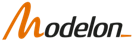
</a>
</div>

In [ ]:
import os
from time import sleep
from urllib.parse import parse_qs
import ipywidgets as widgets
from IPython.display import HTML
import plotly.graph_objects as go
from modelon.impact.client import Client
from modelon.impact.client.sal.exceptions import HTTPError
from modelon.impact.client.operations import Status
import base64
import hashlib
import threading

In [ ]:
# CUSTOM PARTS (model, parameters, receclares)

workspaceid = "el2024p1" # default (URL can override)

modelname = "Electrification.Batteries.Experiments.Verification.StaticDischarge"

# RESULTS (variables to save, plot, and export)

result_variables = {
    "batteryPack.summary.SoC": "SOC [0..1]",
    "batteryPack.summary.v": "Voltage [V]",
    "batteryPack.summary.i": "Current [A]",
    "batteryPack.summary.T_cell_max": "Temperature [K]"}

# PARAMETERS

# parameter: fixed_temperature
par_fixT = widgets.Checkbox(
    value=True,
    description='Fixed temperature',
    disabled=False,
    indent=False
)
par_fixT.key = "batteryPack.fixed_temperature"
par_fixT.style.description_width = 'auto'

# parameter: T0
par_T0 = widgets.FloatText(
    value=293.15,
    step=5,
    description="Start temperature [K]:",
    disabled=False,
)
par_T0.key = "batteryPack.thermal.T0"
par_T0.style.description_width = 'auto'

# parameter: C-rate
par_rate = widgets.BoundedFloatText(
    value=0.5,
    min=0.0,
    max=1.0,
    step=0.1,
    description="C-rate (discharge):",
    disabled=False,
)
par_rate.key = "reference.k"
par_rate.style.description_width = 'auto'

# replaceable battery core
options_core = [
    ("Default", ""),
    ("LFP", ".Electrification.Batteries.Core.Examples.LFP.Tabular"),
    ("NCA", ".Electrification.Batteries.Core.Examples.NCA.Characteristic"),
]
dropdown_core = widgets.Dropdown(
    options=options_core,
    description='Core:',
)
dropdown_core.style.description_width = 'auto'

# parameter box widget
box_par = widgets.VBox([
    widgets.Label(value="Cell", layout=widgets.Layout(display="flex", justify_content="center")),
    dropdown_core,
    widgets.Label(value="Boundary", layout=widgets.Layout(display="flex", justify_content="center")),
    par_rate,
    widgets.Label(value="Thermal", layout=widgets.Layout(display="flex", justify_content="center")),
    par_fixT,
    par_T0])

# METHODS
def get_parameters():
    return {
        par_rate.key: par_rate.value, 
        par_fixT.key: par_fixT.value, 
        par_T0.key: par_T0.value}

def get_redeclare_string():
    if not dropdown_core.value:
        return ""
    else:
        return f"(batteryPack(redeclare {dropdown_core.value} core))"


In [ ]:
# IMPACT SETUP (get the workspace and specific model)

query_string = os.environ.get('QUERY_STRING', '')
parameters = parse_qs(query_string)
workspaceid =  parameters.get('workspaceId', [workspaceid])[0] # Get workspace id from the URL (or use default)
client = Client()
workspace = client.get_workspace(workspaceid)
model = workspace.get_model(modelname)
dynamic = workspace.get_custom_function('dynamic')

In [ ]:
# CHECK FOR UPDATE TO THE APP

pwc = client.get_published_workspaces_client()
if workspace.definition.received_from:
    try:
        published_workspace = pwc.get_by_id(workspace.definition.received_from.sharing_id)
        if published_workspace.created_at > workspace.definition.received_from.created_at:
            print("An update is available!")
        else:
            print("The app is up to date.")
    except HTTPError:
        print("Warning: The app is no longer published!")

In [ ]:
# METHODS (general)

def get_sims():
    experiments_in_ws = workspace.get_experiments()
    sims = []
    for exp in experiments_in_ws:
        modelpath = exp.get_class_name().split('(')[0]
        if modelpath == modelname and exp.is_successful():
            sims.append(exp)
    return sims

def get_sim_names():
    names = []
    for sim in get_sims():
        names.append(sim.metadata.label)
    return names

def get_variable_options():
    return [(description, path) for path, description in result_variables.items()]

def get_variable_filter_string(varmap):
    filter = ""
    for path in varmap.keys():
        if len(filter) > 0:
            filter += ','
        filter += '"' + path + '"'
    return '[' + filter + ']'

def get_experiment_definition(ncp,endtime,filter=''):
    redeclare_string = get_redeclare_string()
    model_with_redeclares = workspace.get_model(model.name + redeclare_string)
    modifiers = get_parameters()
    simulation_options = dynamic.get_simulation_options().with_values(
        filter=filter,
        ncp=ncp)
    solver_options = {'store_event_points':False}
    experiment_definition_base = model_with_redeclares.new_experiment_definition(
        dynamic.with_parameters(start_time=0, final_time=endtime),
        simulation_options=simulation_options,
        solver_options=solver_options)
    experiment_definition = experiment_definition_base.with_modifiers(modifiers)
    return experiment_definition

def generate_csv(sim):
    filename = 'result.csv'
    c = sim.get_cases()[0]
    data, dummyname = c.get_result(format='csv')
    with open(filename, "w") as f:
        f.write(data)
    return filename

def get_download_html(filename):
    with open(filename, "br") as file:
        contents = file.read()
    b64 = base64.b64encode(contents)
    payload = b64.decode()
    digest = hashlib.md5(contents).hexdigest()  # bypass browser cache
    id = f'dl_{digest}'
    filename_base = os.path.basename(filename)
    return HTML(f"""
<html>
<body>
<a id="{id}" download="{filename_base}" href="data:text/csv;base64,{payload}" download>
</a>

<script>
(function download() {{
document.getElementById('{id}').click();
}})()
</script>

</body>
</html>
""")


In [ ]:
# MAIN USER INTERACE

# BOX: Experiment

par_endtime = widgets.BoundedFloatText(
    value=7200.0,
    min=0.0,
    max=86400.0,
    step=100.0,
    description="End time:",
    disabled=False,
)
par_endtime.style.description_width = 'auto'

par_ncp = widgets.BoundedIntText(
    value=500,
    min=0,
    max=1000000000,
    step=100,
    description="Result points (NCP):",
    disabled=False,
)
par_ncp.style.description_width = 'auto'

new_sim_name = widgets.Text(
    value='NoName',
    placeholder='Type something',
    description='Name:',
    disabled=False
)
new_sim_name.style.description_width = 'auto'
button_sim = widgets.Button(description='Simulate', operation = None)
output_sim = widgets.Output()
box_exp = widgets.VBox([par_endtime, par_ncp, new_sim_name, button_sim, output_sim])

# BOX: Simulations

select_sims = widgets.SelectMultiple(
    options=get_sim_names(),
    rows=10,
    disabled=False
)

button_remove = widgets.Button(description='Remove',disabled=True)
button_export = widgets.Button(description='Export CSV',disabled=True)
output_export = widgets.Output()

box_sim = widgets.VBox([select_sims, button_remove, button_export, output_export])

# BOX: Sidebar

lay_side = widgets.Layout(width='30%',max_width='400px')
box_side = widgets.widgets.VBox([
    widgets.widgets.Accordion(children=[box_par], titles=('Parameters',)),
    widgets.widgets.Accordion(children=[box_exp], titles=('Experiment',)),
    widgets.Accordion(children=[box_sim], titles=('Simulations',))], layout = lay_side)

# BOX: Plotting
dropdown_var1 = widgets.Dropdown(
    options=get_variable_options(),
    description='Variable:',
)

fig = go.FigureWidget()

lay_plot = widgets.Layout(display='flex', flex_flow='column', align_items='stretch')
box_plot = widgets.VBox([dropdown_var1,fig], layout = lay_plot)

# BOX: Main
lay_main = widgets.Layout(width='100%')
box_main = widgets.HBox([box_side, box_plot], layout = lay_main)

In [ ]:
# METHODS (user events)

def on_var1(change):
    draw_plots()

def on_select(change):
    count = len(select_sims.index)
    if count < 1:
        button_remove.disabled = True
        button_export.disabled = True
    elif count > 1:
        button_remove.disabled = False
        button_export.disabled = True
    else:
        button_remove.disabled = False
        button_export.disabled = False
    draw_plots()

def wait_for_simulation(operation,output):
    while operation.status not in (Status.DONE, Status.CANCELLED):
        output.append_stdout(f"{operation.status.value}")
        sleep(0.5)
        output.outputs = ()
    button_sim.on_click(on_abort, remove=True)
    experiment = operation.data()
    if operation.status is Status.CANCELLED:
        output.append_stdout("Last simulation was cancelled.")
    elif experiment.is_successful():
        output.append_stdout("Last simulation succeeded.")
        experiment.set_label(new_sim_name.get_interact_value())
    else:
        case = experiment.get_cases()[0]
        output.append_stdout(case.get_log())
    select_sims.options = get_sim_names()
    button_sim.on_click(on_simulate)
    button_sim.description = button_sim.description_default

def on_simulate(b):
    button_sim.on_click(on_simulate, remove=True)
    button_sim.description_default = button_sim.description
    button_sim.description = "Abort"
    output_sim.clear_output()
    experiment_definition = get_experiment_definition(
        ncp=par_ncp.value,
        endtime=par_endtime.value,
        filter=get_variable_filter_string(result_variables))
    b.operation = workspace.execute(experiment_definition)
    thread = threading.Thread(
        target=wait_for_simulation,
        args=(b.operation,output_sim))
    thread.start()
    button_sim.on_click(on_abort)

def on_abort(b):
    if b.operation is not None:
        b.operation.cancel()

def on_remove(b):
    sims_all = get_sims()
    sims_sel = [sims_all[i] for i in select_sims.index]
    for sim in sims_sel:
        sim.delete()
    select_sims.options = get_sim_names()

def on_export(b):
    sims = get_sims()
    x = select_sims.index[0]
    filename = generate_csv(sims[x])
    html = get_download_html(filename)
    with output_export:
        display(html)

def draw_plots():
    fig.data = []
    path_var1 = dropdown_var1.get_interact_value()
    sims_all = get_sims()
    sims_sel = [sims_all[i] for i in select_sims.index]
    for sim in sims_sel:
        label = sim.metadata.label
        case = sim.get_cases()[0]
        res = case.get_trajectories()
        fig.add_trace(go.Scatter(x=res['time'], y=res[path_var1], mode='lines', name=label))

# Register callback methods
button_sim.on_click(on_simulate)
button_remove.on_click(on_remove)
button_export.on_click(on_export)
dropdown_var1.observe(on_var1, names='value')
select_sims.observe(on_select, names='index')

In [ ]:
# DISPLAY THE INTERFACE
display(box_main)